# 🚗 Car Price Prediction Using Machine Learning

## Objective

The objective of this project is to predict the selling price of a used car using machine learning. The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../data/car_data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [11]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [13]:
df.drop("Car_Name", axis=1, inplace=True)

In [14]:
current_year = 2025

df["Car_Age"] = current_year - df["Year"]

In [15]:
df.drop("Year", axis=1, inplace=True)

In [16]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

In [17]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')

In [18]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance
------------------------------
MAE : 1.216374019333035
MSE : 3.4813498305118156
RMSE: 1.8658375680942367
R² Score: 0.8488707839193155


In [23]:
# Correlation Matrix

df.corr()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
Selling_Price,1.000000,0.878914,0.029187,-0.088344,-0.236141,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,0.878914,1.000000,0.203618,0.008058,0.047192,0.473390,-0.465326,-0.512121,-0.348776
Driven_kms,0.029187,0.203618,1.000000,0.089216,0.524342,0.172515,-0.172874,-0.101419,-0.162510
Owner,-0.088344,0.008058,0.089216,1.000000,0.182104,-0.053469,0.055687,0.124269,-0.050316
Car_Age,-0.236141,0.047192,0.524342,0.182104,1.000000,-0.064315,0.059959,0.039896,-0.000394
Fuel_Type_Diesel,0.552339,0.473390,0.172515,-0.053469,-0.064315,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.540571,-0.465326,-0.172874,0.055687,0.059959,-0.979648,1.000000,0.358321,0.091013
Selling_type_Individual,-0.550724,-0.512121,-0.101419,0.124269,0.039896,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,-0.367128,-0.348776,-0.162510,-0.050316,-0.000394,-0.098643,0.091013,0.063240,1.000000


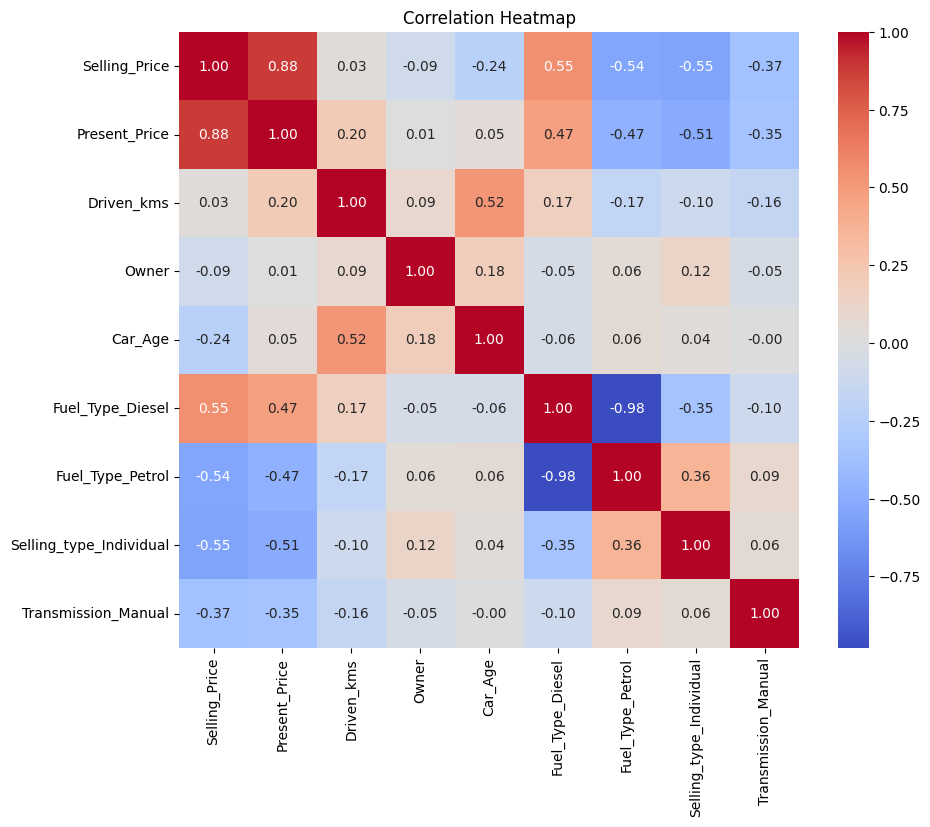

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

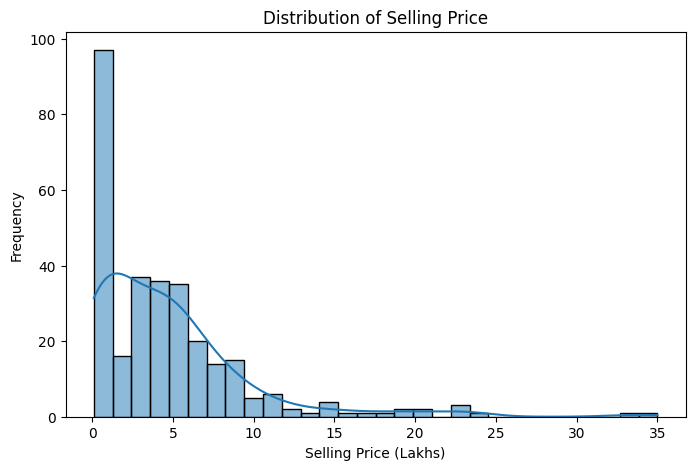

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")

plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Frequency")

plt.show()

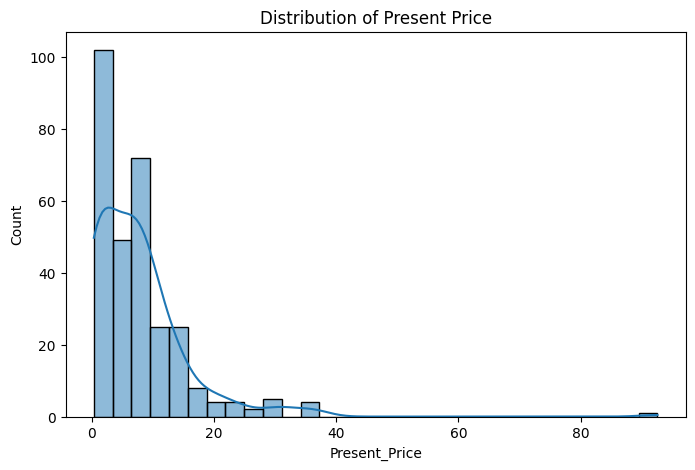

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["Present_Price"], bins=30, kde=True)

plt.title("Distribution of Present Price")

plt.show()

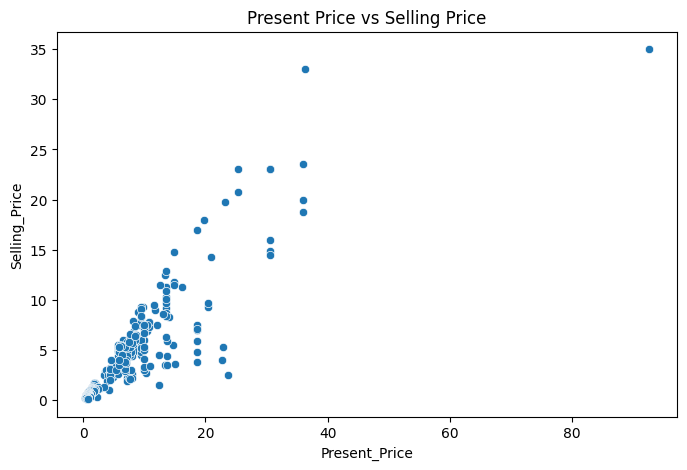

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Present_Price"],
    y=df["Selling_Price"]
)

plt.title("Present Price vs Selling Price")

plt.show()

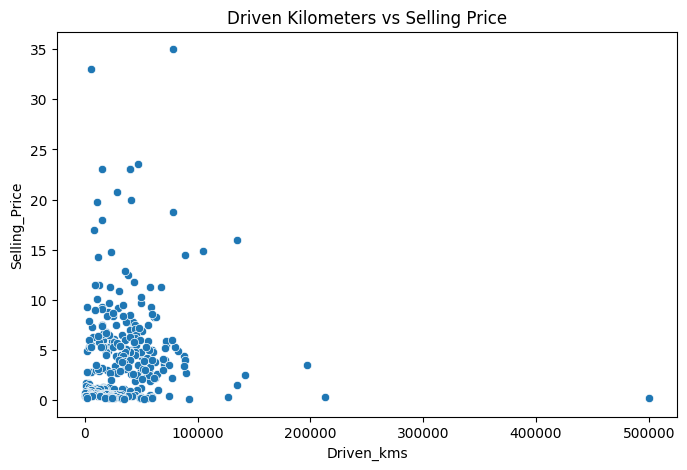

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Driven_kms"],
    y=df["Selling_Price"]
)

plt.title("Driven Kilometers vs Selling Price")

plt.show()

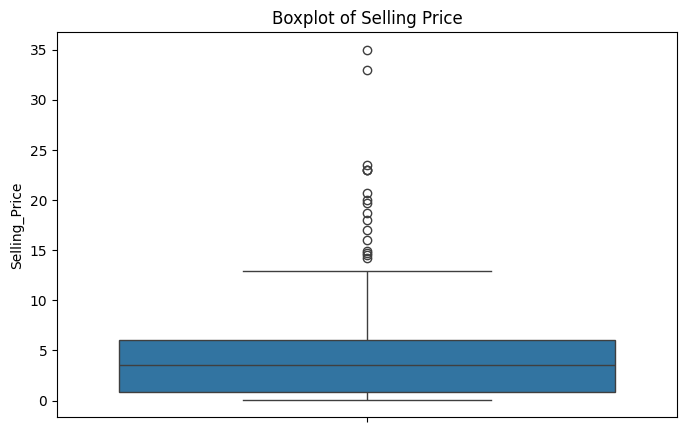

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Selling_Price"])

plt.title("Boxplot of Selling Price")

plt.show()

In [30]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (240, 8)
Testing Data : (61, 8)


In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
177,0.35,2.954337
289,10.11,8.177163
228,4.95,6.456123
198,0.15,-1.423372
60,6.95,9.088647
9,7.45,7.417936
118,1.10,1.335139
154,0.50,0.840323
164,0.45,1.363202
33,6.00,7.490678


In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance
------------------------------
MAE : 1.216374019333035
MSE : 3.4813498305118156
RMSE: 1.8658375680942367
R² Score: 0.8488707839193155


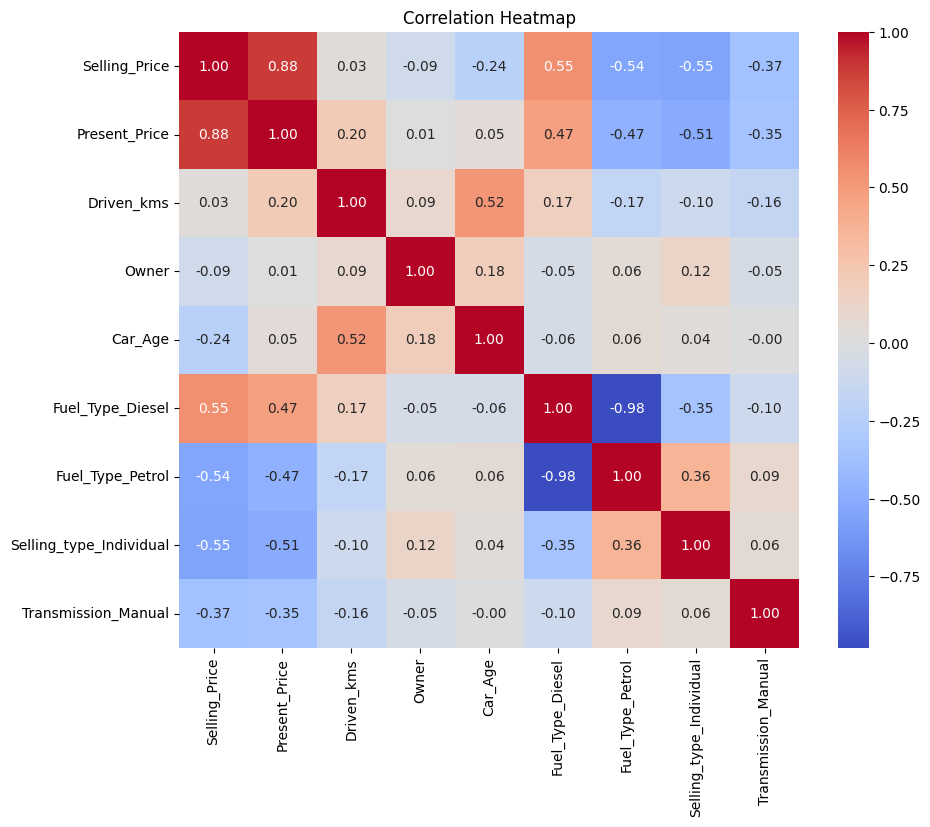

In [35]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("../images/heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

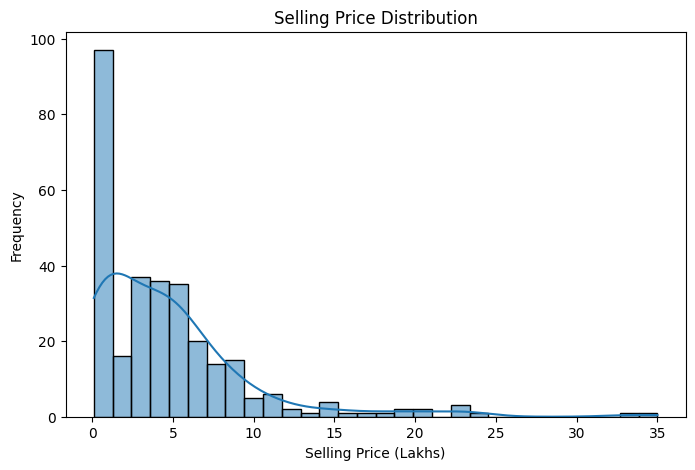

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Selling Price Distribution")

plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Frequency")

plt.savefig("../images/selling_price_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

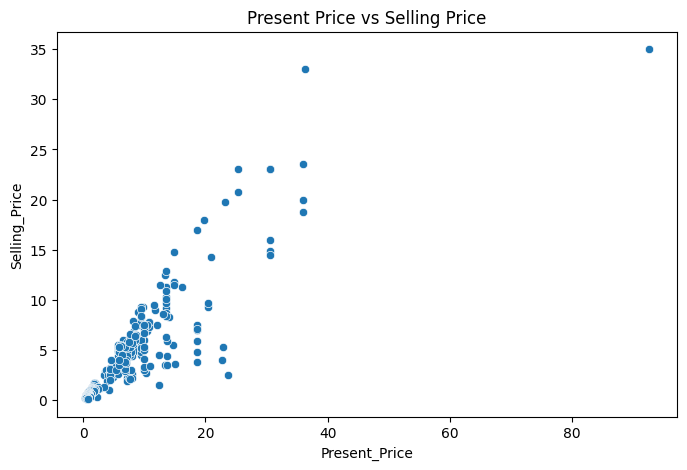

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Present_Price"],
    y=df["Selling_Price"]
)

plt.title("Present Price vs Selling Price")

plt.savefig("../images/present_vs_selling.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

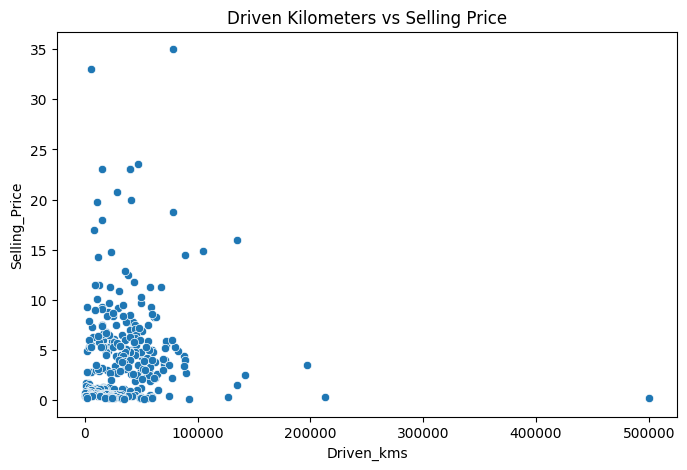

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Driven_kms"],
    y=df["Selling_Price"]
)

plt.title("Driven Kilometers vs Selling Price")

plt.savefig("../images/drivenkms_vs_selling.png",
            dpi=300,
            bbox_inches="tight")

plt.show()